In [12]:
import time, copy
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

from adoptionopinions_model import initial_state_factory, simulation_constants_factory, Simulation
from networks import network_factory, regular_lattice, random_complete

%load_ext autoreload
%autoreload 2
print("done")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
done


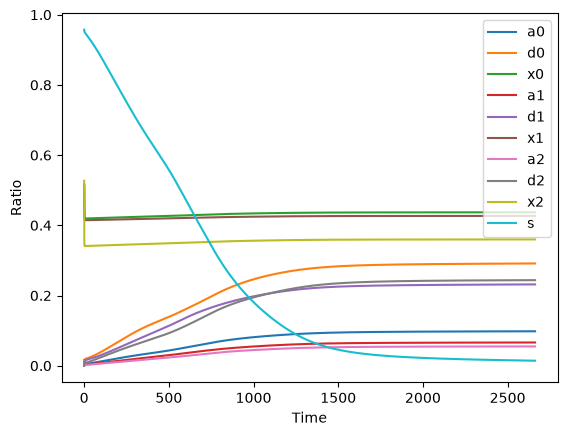

2 -> 0 dominates 9.807% of the population. 2 at 5.489%.


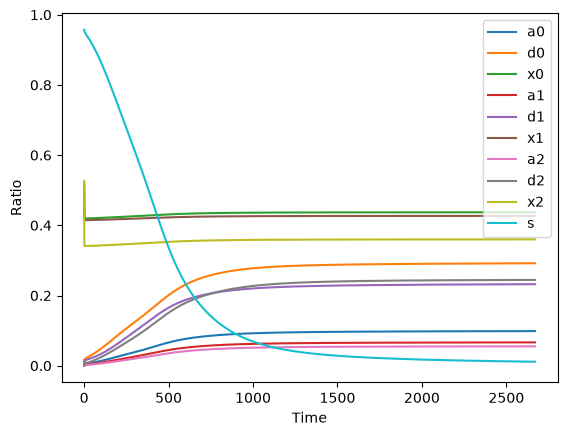

4 -> 0 dominates 9.859% of the population. 2 at 5.512%.


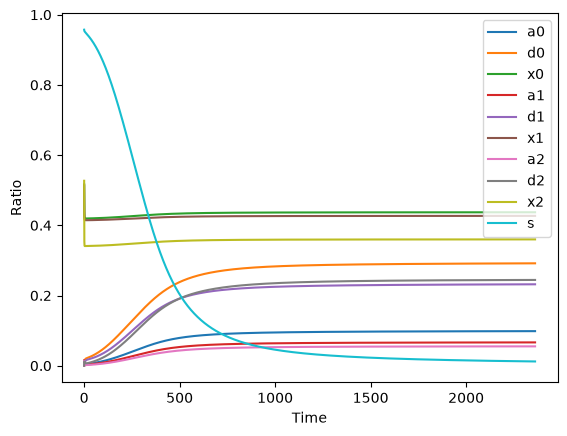

8 -> 0 dominates 9.845% of the population. 2 at 5.509%.


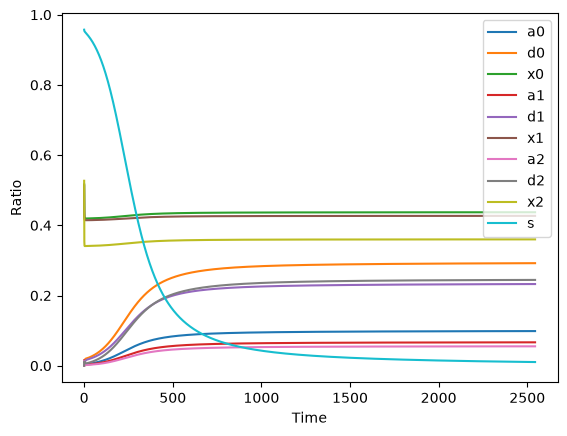

16 -> 0 dominates 9.862% of the population. 2 at 5.519%.


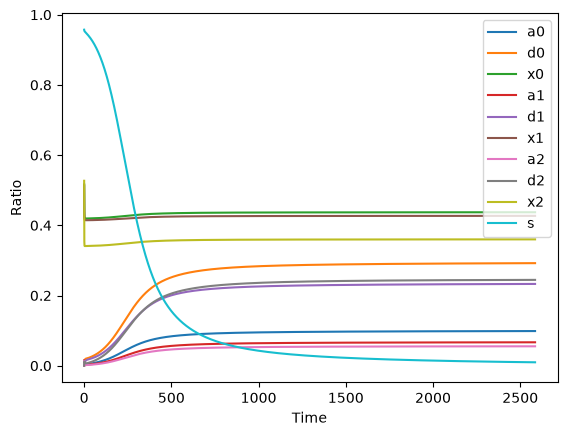

32 -> 0 dominates 9.869% of the population. 2 at 5.526%.


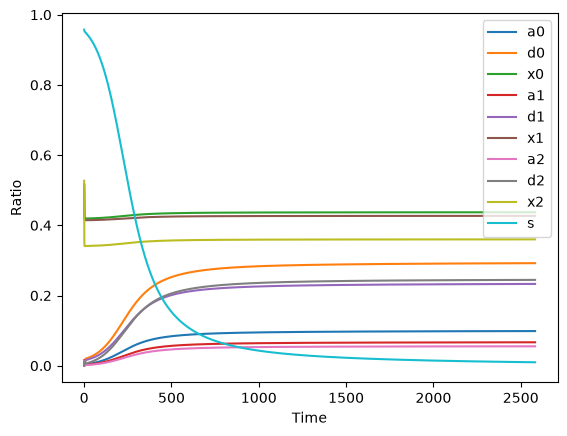

64 -> 0 dominates 9.866% of the population. 2 at 5.525%.


In [13]:
def run(n, k):
    def expo(n):
        for i in range(1,20):
            if n == 2 ** i + 1:
                return i
        assert False
        
    adoptions = []
    initial_states = initial_state_factory(n,k)
    constants      = simulation_constants_factory(n,k,initial_states.x)
    net            = network_factory(n, topology="default")
    number_of_neighbors = [2**i for i in range(1,expo(n) + 1)]
    net.V = random_complete(n)
    for degree in number_of_neighbors:
        net.W = regular_lattice(n, degree)

        #print(np.log2(degree)/int(np.log2(number_of_neighbors[-1])))
        #constants.set_beta( np.array([[np.log2(degree)/int(np.log2(number_of_neighbors[-1]))] * n for _ in range(k)]))
        sim = Simulation(constants, initial_states, net)
        while (not sim(True)):
            pass
        print(f"{degree} -> {sim}")
        #adoptions.append([state.a for state in sim.states])
run(65, 3)

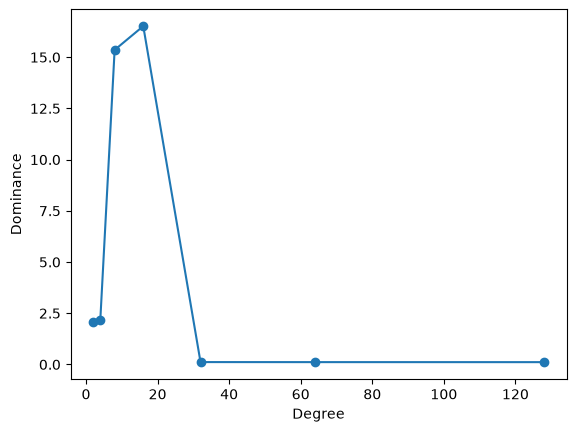

In [4]:
import matplotlib.pyplot as plt

# Data

degrees = [2**i for i in range(1,8)]
dominance = [2.068, 2.183, 15.356, 16.517, 0.116, 0.114, 0.113,]
plt.plot(degrees, dominance, marker='o')
plt.xlabel("Degree")
plt.ylabel("Dominance")
plt.show()

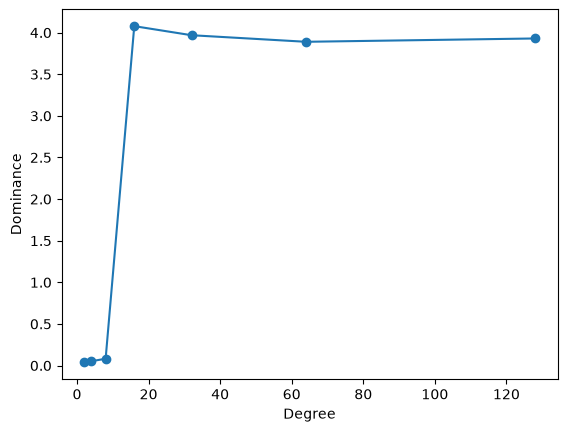

In [17]:

import matplotlib.pyplot as plt

# Data

degrees = [2**i for i in range(1,8)]
dominance = [0.041, 0.052, 0.082, 4.078, 3.969, 3.89, 3.93,]
plt.plot(degrees, dominance, marker='o')
plt.xlabel("Degree")
plt.ylabel("Dominance")
plt.show()